In [1]:
import numpy as np
import matplotlib.pyplot as plt

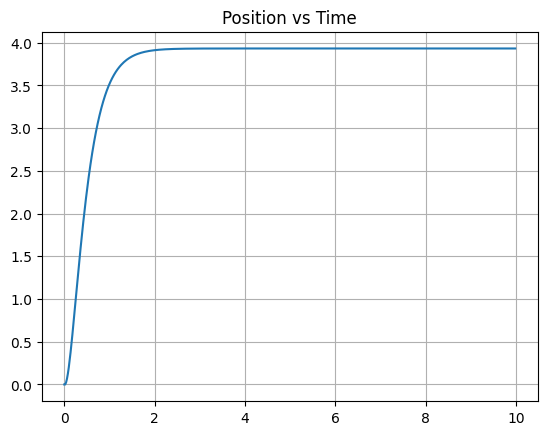

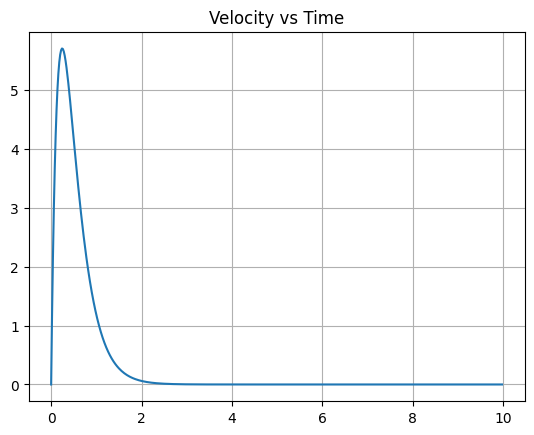

In [2]:
A = np.array([[0, 1], [-3.2, -0.2]])
B = np.array([[0], [1]])
K = np.array([[11.8, 7.8]])

dt = 0.02
time = np.arange(0, 10, dt)
N = time.shape[0]
# define states array
states = np.zeros((N,2))
states[0] = np.array([0, 0])
# define your target states
target = np.array([5, 0])
# for-loop to simulate the system behavior
for idx in range(0, N-1):
    x_now = states[idx]
    error = target - x_now
    u = K@error
    x_dot = A@x_now + B@u
    x_next = x_now + x_dot*dt
    states[idx+1] = x_next

pos = states[:,0]
vel = states[:,1]

plt.figure()
plt.plot(time, pos)
plt.title("Position vs Time")
plt.grid()

plt.figure()
plt.plot(time, vel)
plt.title("Velocity vs Time")
plt.grid()


Text(0, 0.5, 'Velocity')

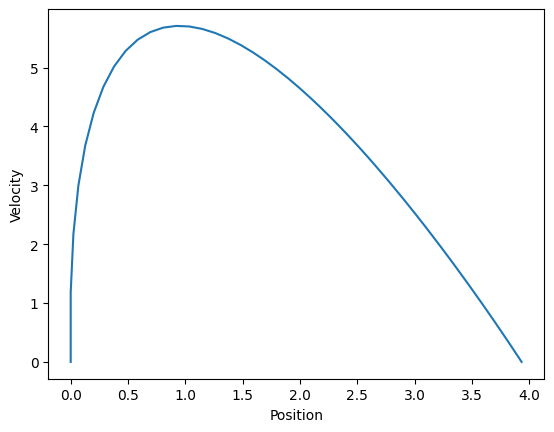

In [3]:
plt.figure()
plt.plot(pos, vel)  
plt.xlabel("Position")
plt.ylabel("Velocity")

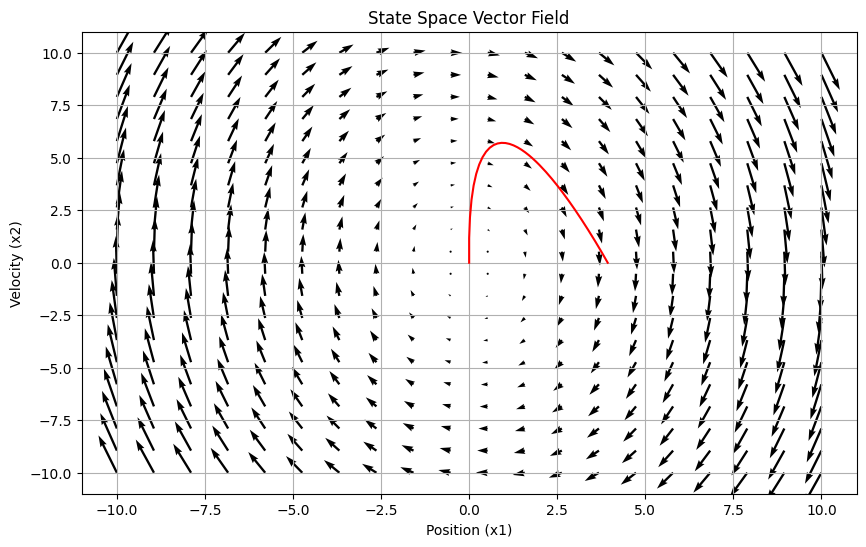

In [4]:
# Define the grid for state space
x1 = np.linspace(-10, 10, 20)  # Position range
x2 = np.linspace(-10, 10, 20)   # Velocity range
X1, X2 = np.meshgrid(x1, x2)

# Initialize vector field arrays
U = np.zeros_like(X1)
V = np.zeros_like(X2)

# Compute vector field
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_now = np.array([X1[i, j], X2[i, j]])
        error = target - x_now
        u = K @ error
        x_dot = A @ x_now 
        U[i, j] = x_dot[0]  # dx/dt (position derivative)
        V[i, j] = x_dot[1]  # dv/dt (velocity derivative)

# Plot the vector field
plt.figure(figsize=(10, 6))
plt.quiver(X1, X2, U, V, angles='xy')
plt.plot(pos, vel, 'r')  
plt.title('State Space Vector Field')
plt.xlabel('Position (x1)')
plt.ylabel('Velocity (x2)')
plt.grid()
plt.show()
